# Plot the Results of Simulated Data (Different Noise Levels)-Combination 3

## Packages Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.metrics.cluster import adjusted_rand_score

import sys
sys.path.append(r'../../../../')
from SpatialCOC.utils import reorder_categories

## Parameter Setting

In [2]:
colors_domain = ['#f19c79', '#e9c46a', '#2a9d8f', '#264653']

font_size = 16

result_key = ['SpatialCOC', 'SpatialGlue', 'COSMOS', 'MultiVI', 'MultiMAP', 'STAGATE', 'SpaGCN', 'Modality1', 'Modality2']

new_order_dict_all = {
    0: {
        'SpatialCOC':   [1, 3, 4, 2],
        'SpatialGlue':  [1, 2, 3, 4],
        'COSMOS':       ['1', '2', '3', '4'],
        'MultiVI':      [4, 2, 3, 1],
        'MultiMAP':     [1, 3, 2, 4],
        'STAGATE':      [2, 3, 1, 4],
        'SpaGCN':       [3, 1, 0, 2],
        'Modality1':    [1, 2, 3, 4],
        'Modality2':    [1, 4, 3, 2]
    },
    1: {
        'SpatialCOC':   [1, 2, 3, 4],
        'SpatialGlue':  [1, 2, 3, 4],
        'COSMOS':       ['1', '2', '3', '4'],
        'MultiVI':      [2, 1, 3, 4],
        'MultiMAP':     [1, 2, 3, 4],
        'STAGATE':      [2, 1, 3, 4],
        'SpaGCN':       [3, 1, 0, 2],
        'Modality1':    [1, 2, 3, 4],
        'Modality2':    [3, 4, 1, 2]
    },
    2: {
        'SpatialCOC':   [1, 2, 3, 4],
        'SpatialGlue':  [1, 2, 3, 4],
        'COSMOS':       ['1', '2', '3', '4'],
        'MultiVI':      [3, 1, 2, 4],
        'MultiMAP':     [1, 2, 3, 4],
        'STAGATE':      [3, 2, 1, 4],
        'SpaGCN':       [3, 0, 1, 2],
        'Modality1':    [1, 2, 3, 4],
        'Modality2':    [1, 2, 3, 4]
    },
    3: {
        'SpatialCOC':   [1, 3, 2, 4],
        'SpatialGlue':  [2, 1, 3, 4],
        'COSMOS':       ['1', '2', '3', '4'],
        'MultiVI':      [3, 1, 2, 4],
        'MultiMAP':     [1, 2, 3, 4],
        'STAGATE':      [2, 1, 3, 4],
        'SpaGCN':       [3, 0, 1, 2],
        'Modality1':    [1, 2, 3, 4],
        'Modality2':    [2, 1, 3, 4]
    }
}

## Plot the Spatial Domain Identifications

Processing noise_level: 0


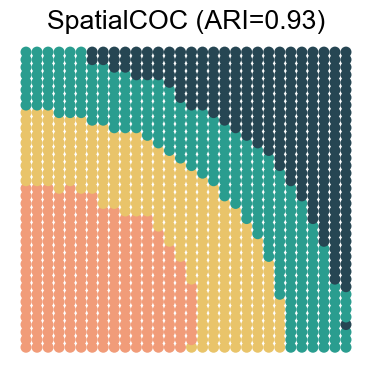

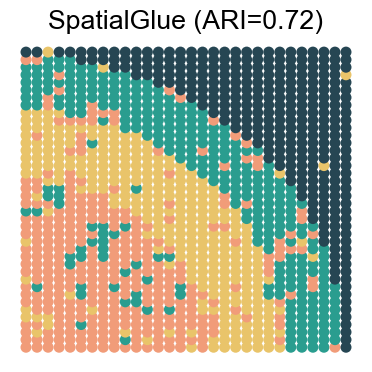

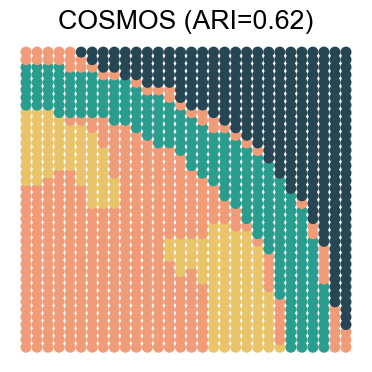

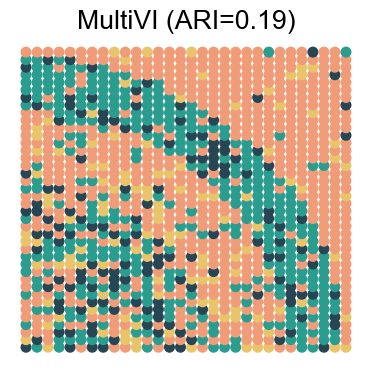

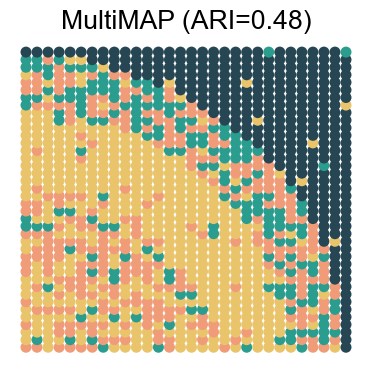

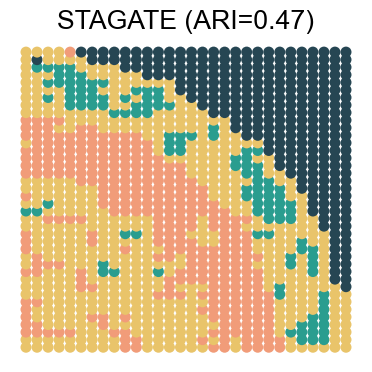

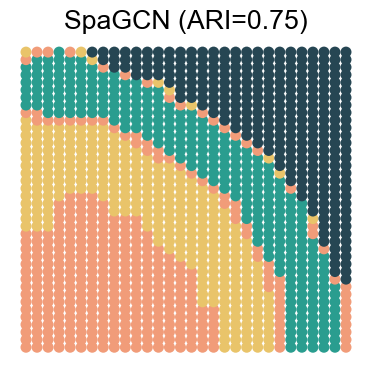

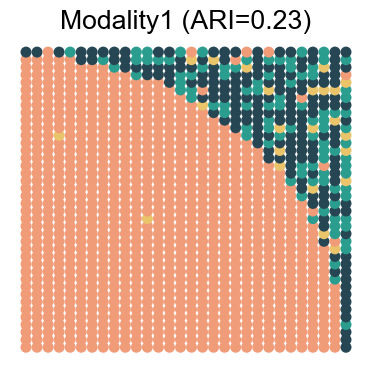

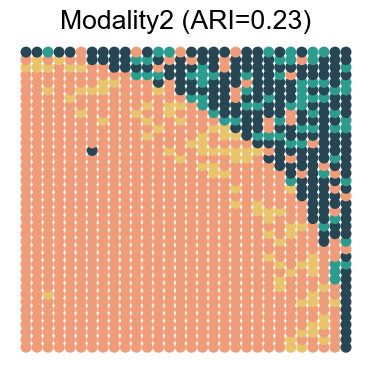

Processing noise_level: 1


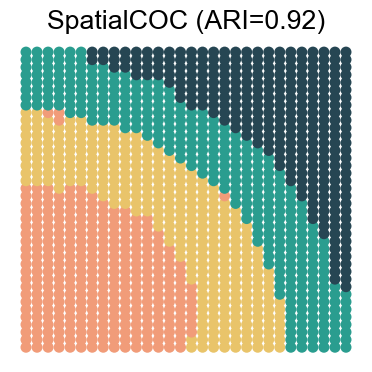

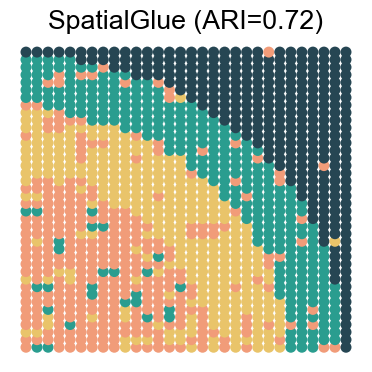

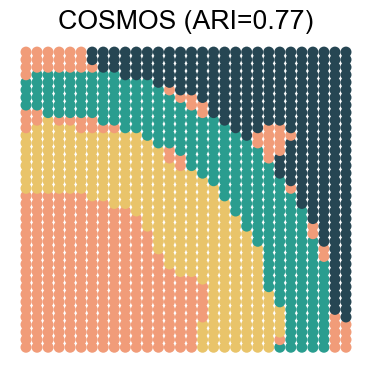

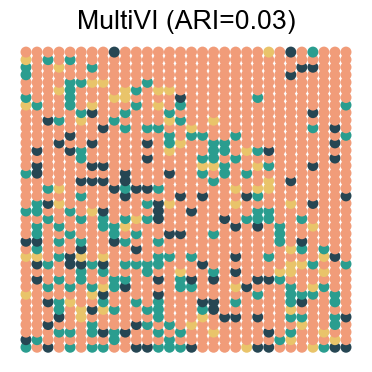

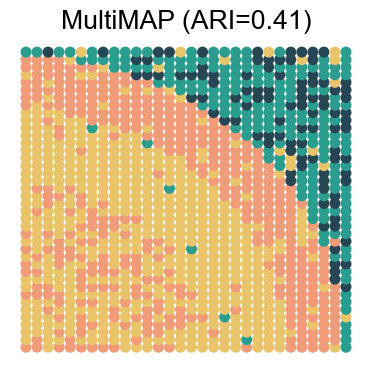

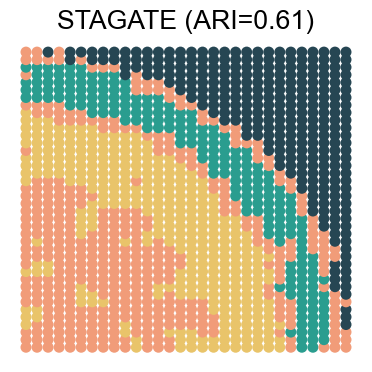

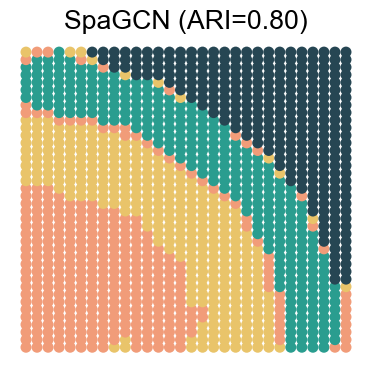

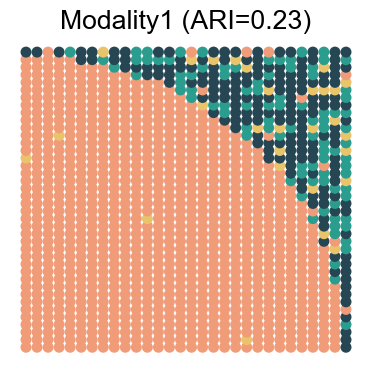

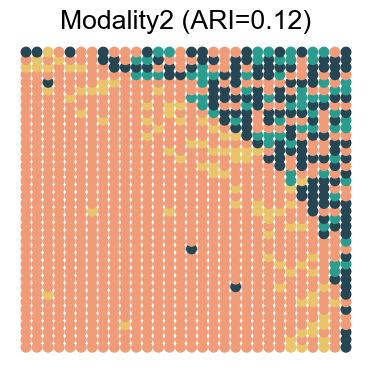

Processing noise_level: 2


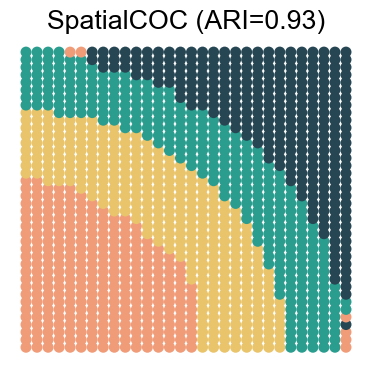

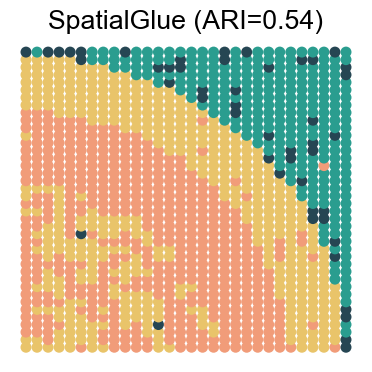

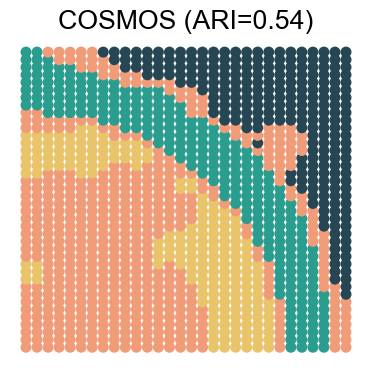

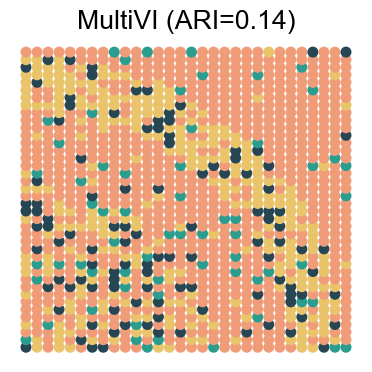

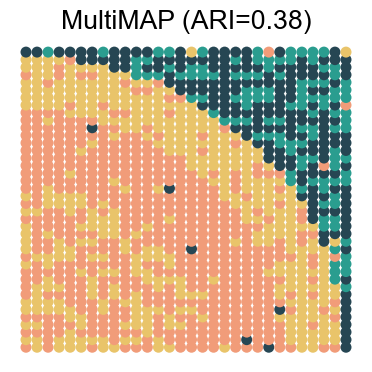

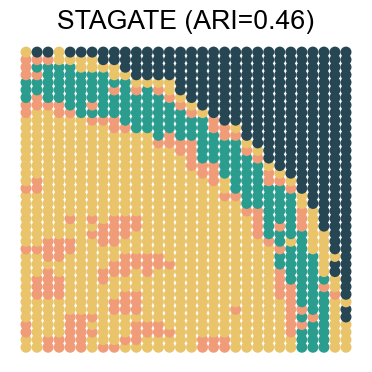

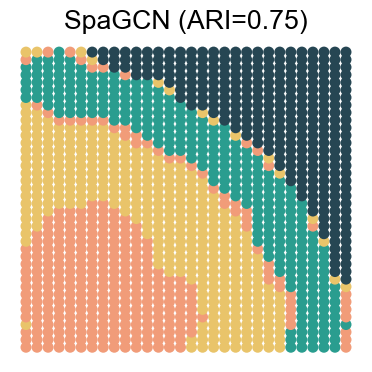

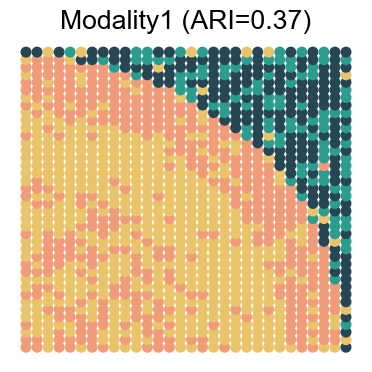

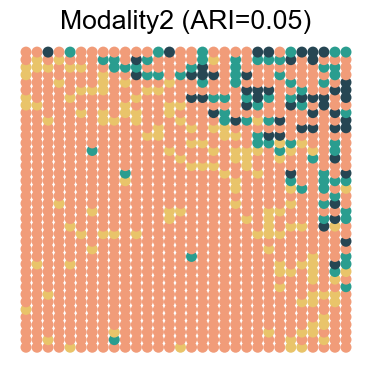

Processing noise_level: 3


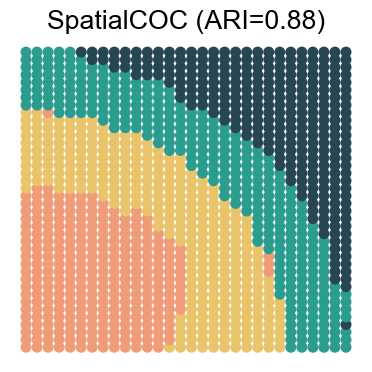

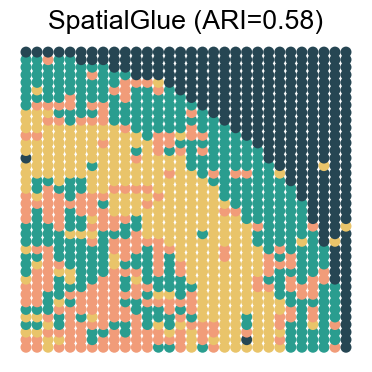

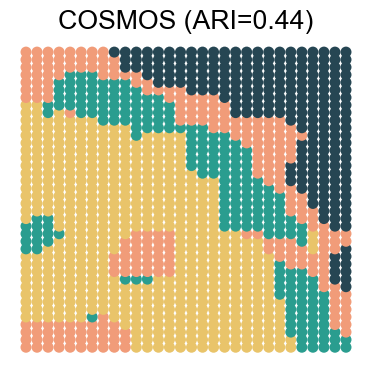

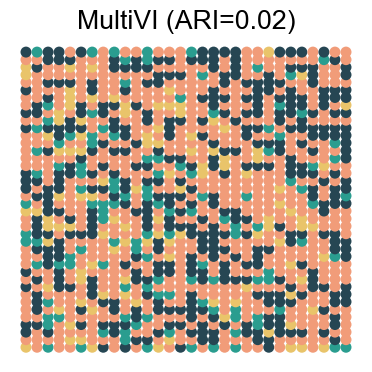

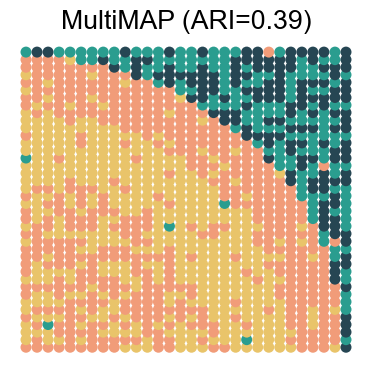

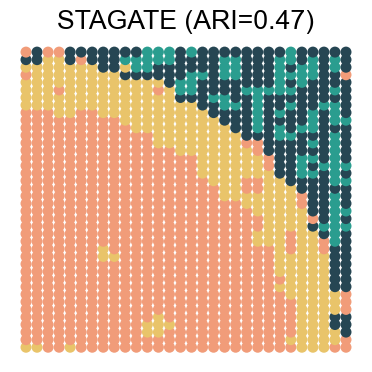

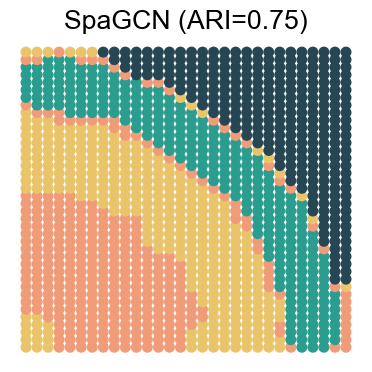

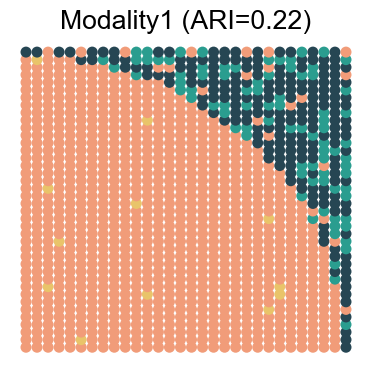

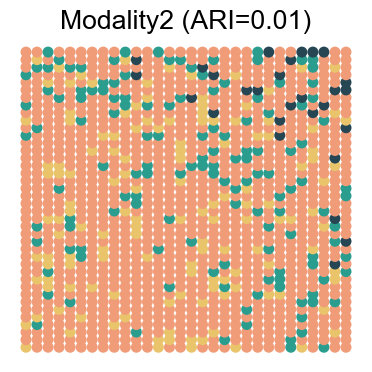

In [3]:
slice_id = 3        # 1, 2, 3, 4
noise_levels = [0, 1, 2, 3]

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = font_size

for noise_level in noise_levels:
   # Loading results
   adata_results = sc.read_h5ad(f'../../../Noise_Combination_{slice_id}.h5ad')
   adata_results = adata_results[adata_results.obs['noise_level'] == noise_level]
   
   save_path = f'../../Noise_Combinations/Combination{slice_id}/'
   new_order_dict = new_order_dict_all[noise_level]
   print(f"Processing noise_level: {noise_level}")
   
   for result in result_key:
       new_order = new_order_dict[result]
       reorder_categories(adata_results, result, new_order)

       # Calculate ARI
       ari_value = adjusted_rand_score(adata_results.obs['Ground Truth'], adata_results.obs[result])

       fig, ax = plt.subplots(1, 1, figsize=(4, 4))
       sc.pl.embedding(
           adata_results,
           basis='spatial',
           color=result,
           title=None,
           s=250,
           colorbar_loc=None,
           show=False,
           ax=ax,
           palette=colors_domain,
           legend_loc=None
       )

       ax.set_title(f"{result} (ARI={ari_value:.2f})")
       ax.set_xlabel('')
       ax.set_ylabel('')

       # Hide axis borders
       for spine in ax.spines.values():
           spine.set_visible(False)

       # Adjust subplot parameters
       plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
       plt.tight_layout()

    #    Saving the results
    #    plt.savefig(f'{save_path}{noise_level}_{result}.png', dpi=500)
    #    plt.savefig(f'{save_path}{noise_level}_{result}.eps')

       plt.show()